In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized_sinbeta_sparse import TVqRegularized
from bimpcc.models.tvq_denoising_sinbeta import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices
from skimage.metrics import structural_similarity as ssim

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title(f'Noisy Image\nPSNR: {psnr(noisy,true):.4f}\n SSIM={ssim(noisy,true, data_range=1.0):.4f}')
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n SSIM={ssim(noisy,true, data_range=1.0):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')
    
    plt.show()
    return psnr(true,noisy),psnr(true,u)

In [4]:
scale = 40

In [5]:
ruido = 0.015

In [6]:
nombre_img = "cameraman"
dataset = get_dataset(nombre_img,scale=scale, random_state=1,desv_est=ruido)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(39.5), np.float64(39.5), np.float64(-0.5))

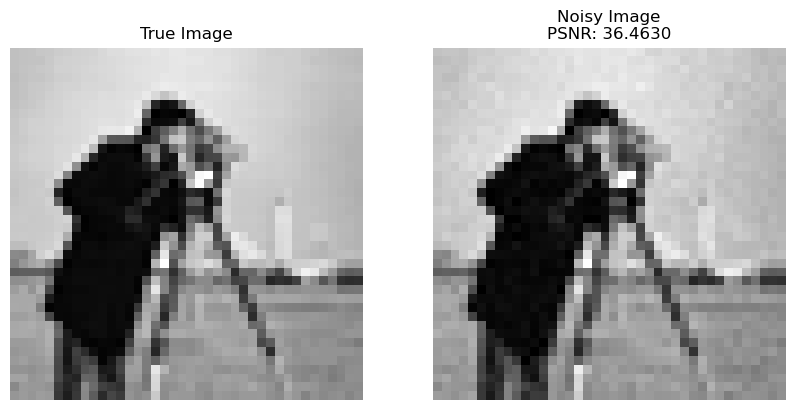

In [7]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [33]:
q_param = 0.7

In [34]:
model = TVqRegularized(true, noisy, epsilon=0, q_param=q_param)

In [35]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

[100.]
[100.]
[100.]
[99.97380158]
[100.7558352]
[99.37754738]
[107.44037497]
[107.45677539]
[107.40730569]
[101.606143]
[103.40631109]
[106.78546009]
[115.88034582]
[113.44541221]
[108.52990885]
[105.4380041]
[106.653441]
[105.48226563]
[94.53492018]
[105.48226563]
[105.48321859]
[56.13589438]
[105.48321859]
[105.47838984]
[105.85753229]
[109.85228202]
[106.52700229]
[127.63312017]
[124.85262268]
[238.31273431]
[73.78558331]
[103.48333811]
[131.49410044]
[148.82581791]
[222.45846115]
[174.06428468]
[123.79750319]
[188.0776204]
[163.46658822]
[163.45657508]
[163.46063966]
[163.46891421]
[163.46759766]
[163.46858705]
[163.46746003]
[163.45934563]
[163.45197156]
[163.46015151]
[163.45291008]
[163.44446051]
[163.43891211]
[163.45773804]
[163.44715833]
[163.45219113]
[163.44185644]
[163.47046818]
[163.42422917]
[163.42376453]
[163.41330598]
[163.41836745]
[163.41284308]
[163.41817565]
[163.41291985]
[163.41788168]
[163.4126719]
[163.41774408]
[163.41398308]
[163.42029774]
[163.43697491]
[1

In [36]:
print(open("ipopt.log", "r", encoding="utf-8", errors="ignore").read()[:5000])

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    78060
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     4721
                     variables with only lower bounds:     1601
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     4720
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.7860147e-01 2.89e+00 9.98e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [37]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

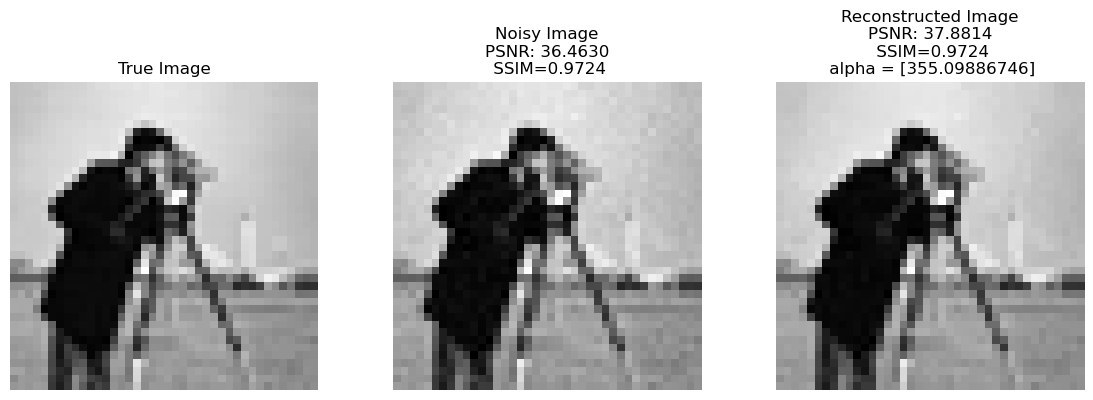

In [38]:
u_scaled = u.reshape((scale,scale))
psnr_n, psnr_r = plot_experiment(true,noisy,u_scaled,alpha)

In [39]:
from pathlib import Path
from imageio import imwrite

In [40]:
base_dir = Path("results_tvq")

# Rutas
dir_img = base_dir / nombre_img
dir_regularizado = dir_img / f"reg_{scale}_ruid_{ruido}"

# Crear carpetas si no existen
dir_regularizado.mkdir(parents=True, exist_ok=True)
out_dir = Path("results_tvq") / nombre_img / f"reg_{scale}_ruid_{ruido}"
out_dir.mkdir(parents=True, exist_ok=True)

In [41]:
out_dir_2 = Path("results_tvq") / nombre_img
out_path_t = out_dir_2 / f"true_{nombre_img}_{scale}_ruido_{ruido}.png"
imwrite(str(out_path_t), (true * 255).astype(np.uint8))

In [42]:
out_path_n = out_dir_2 / f"noisy_{nombre_img}_{scale}_{psnr_n:.4f}_ruido_{ruido}.png"
imwrite(str(out_path_n), (noisy * 255).astype(np.uint8))

In [43]:
out_path_r = out_dir / f"recons_{nombre_img}_{scale}_{psnr_r:.4f}_{alpha[0]:.2f}_q_{q_param}.png"
imwrite(str(out_path_r), (u_scaled * 255).astype(np.uint8))

In [44]:
Kx, Ky, K = generate_2D_gradient_matrices(scale)

In [45]:
m = q.flatten().size
n = m // 2

Ku = K @ u.flatten()
V = Ku.reshape(2, -1).T
normKu = np.apply_along_axis(np.linalg.norm, axis=1, arr=V)
Q = q.reshape(2,-1).T
normQ = np.apply_along_axis(np.linalg.norm, axis=1, arr=Q)
r0 = normKu
delta0 = normQ

In [46]:
Kxu = Ku[:n]  # Primeras n componentes
Kyu = Ku[n:]  # Últimas n componentes
qx = q[:n]  # Primeras n componentes
qy = q[n:]  # Últimas n componentes
epsilon = 1e-10  

# Condiciones para calcular theta según los casos dados
theta0 = np.zeros(n)  # Inicializamos theta0

# Caso 1: r_i ≠ 0
mask_r_nonzero = r0 > epsilon
theta0[mask_r_nonzero] = np.arccos(Kxu[mask_r_nonzero] / r0[mask_r_nonzero])
theta0[mask_r_nonzero & (Kyu < 0)] *= -1  # Si Ky^i u < 0, negamos theta0

# Caso 2: r_i = 0 y delta_i ≠ 0
mask_r_zero_delta_nonzero = (r0 <= epsilon) & (delta0 > epsilon)
theta0[mask_r_zero_delta_nonzero] = np.arccos(qx[mask_r_zero_delta_nonzero] / delta0[mask_r_zero_delta_nonzero])
theta0[mask_r_zero_delta_nonzero & (qy < 0)] *= -1  # Si qy^i < 0, negamos theta0

# Caso 3: r_i = 0 y delta_i = 0 (theta0 indefinido)
mask_r_zero_delta_zero = (r0 <= epsilon) & (delta0 <= epsilon)
theta0[mask_r_zero_delta_zero] = 0

In [47]:
x0_mpcc = np.concatenate((u.flatten(),q.flatten(),r0,delta0,theta0,alpha))
# print(x0_mpcc)

In [48]:
mpcc_model = TVDenoisingMPCC(true, noisy, x0=x0_mpcc, epsilon=1e-3, q_param = q_param)

In [49]:
res_mpcc, x_opt_mpcc, fun_opt_mpcc, history = mpcc_model.solve(t_init=1e-3,max_iter=100,tol=1e-5,print_level=5,verbose=True)

Iter   Termination_status            Objective      MPCC_compl               t

0                 0  0.1269496470128776      0.35701249308563365              0.001

1                 0  0.12862094807795907     0.23964410766911368             0.0005

2                 0  0.12957975616913986     0.16612017318182776            0.00025

3                 0  0.13013492738323484     0.1137594822227529            0.000125

...

5                 0  0.13062378054382698     0.05126702865366716          3.125e-05

6                 0  0.1307197861534793      0.031734544584417095        1.5625e-05

Intermediate fn: 0.1307197861534793

complementarity: 0.031734544584417095

* (STOPPED) Iteration 8: Solving the NLP problem for t = 1e-05 with complementarity: 0.031734544584417095

In [50]:
print(open("ipopt_mpcc.log", "r", encoding="utf-8", errors="ignore").read()[:5000])

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    90540
Number of nonzeros in inequality constraint Jacobian.:     4680
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     9401
                     variables with only lower bounds:     4721
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     7840
Total number of inequality constraints...............:     3120
        inequality constraints with only lower bounds:     3120
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.3058353e-01 4.38e-01 1.05e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

In [51]:
u_mpcc, q_mpcc, r_mpcc, delta_mpcc, theta_mpcc, alpha_mpcc = mpcc_model.objective_func.parse_vars(x_opt_mpcc)

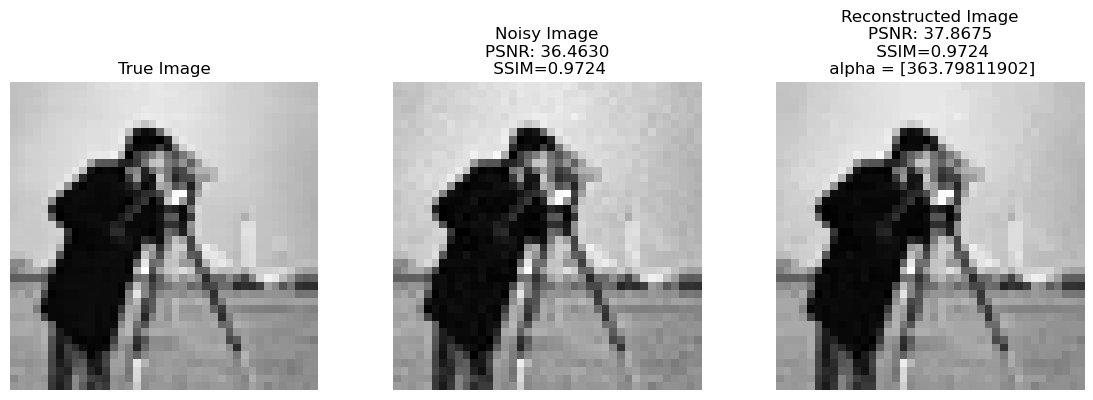

In [52]:
u_mpcc_scaled = u_mpcc.reshape((scale,scale))
psnr_n_mpcc, psnr_r_mpcc = plot_experiment(true,noisy,u_mpcc_scaled,alpha_mpcc)

In [53]:
def history_to_latex(
    history,
    experiment_name="tabla_mpcc",
):
    def fmt(x):
        if x is None:
            return "-"
        if isinstance(x, int):
            return f"{x}"
        x = float(x)
        # Formato decimal fijo, sin notación científica
        s = f"{x:.5f}"          # ajusta decimales si quieres
        s = s.rstrip('0').rstrip('.')  # limpia ceros finales
        return s

    lines = []
    lines.append("\\begin{tabular}{c c c c c c}")
    lines.append("\\toprule")
    lines.append("Iter & Compl & NLP iter & Fun Obj & $t$ & $\\alpha$ \\\\")
    lines.append("\\midrule")

    for row in history:
        lines.append(
            f"{fmt(row['k'])} & "
            f"{fmt(row['comp'])} & "
            f"{fmt(row['nlp_iter'])} & "
            f"{fmt(row['obj'])} & "
            f"{fmt(row['t'])} & "
            f"{fmt(row['alpha'])} \\\\"
        )

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")

    latex_table = "\n".join(lines)

    # -----------------------------
    # Crear carpeta y guardar
    # -----------------------------
    results_dir = "results_table"
    os.makedirs(results_dir, exist_ok=True)

    table_path = os.path.join(results_dir, f"{experiment_name}.tex")
    with open(table_path, "w", encoding="utf-8") as f:
        f.write(latex_table)

    print(f"Tabla LaTeX guardada en: {table_path}")

    return 

In [54]:
history_to_latex(
    history,
    experiment_name=(f"tabla_mpcc_{nombre_img}_{scale}_{q_param}_ruid_{ruido}"),
)

Tabla LaTeX guardada en: results_table\tabla_mpcc_cameraman_40_0.7_ruid_0.015.tex


In [55]:
from pathlib import Path
from imageio import imwrite

In [56]:
dir_mpcc = dir_img / f"mpcc_{scale}_ruid_{ruido}"

# Crear carpetas si no existen
dir_mpcc.mkdir(parents=True, exist_ok=True)
out_dir_mpcc = Path("results_tvq") / nombre_img / f"mpcc_{scale}_ruid_{ruido}"
out_dir_mpcc.mkdir(parents=True, exist_ok=True)

In [57]:
out_path_mpcc = out_dir_mpcc / f"recons_{nombre_img}_{psnr_r_mpcc:.4f}_{alpha_mpcc[0]:.4f}_q_{q_param}.png"
imwrite(str(out_path_mpcc), (u_mpcc_scaled * 255).astype(np.uint8))